In [1]:

from google.colab import files

uploaded = files.upload()

Saving yoruba_focus_nlp.json to yoruba_focus_nlp.json


In [2]:
import json

filename = "yoruba_focus_nlp.json"

with open(filename, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Number of records:", len(data))
print("First record:")
print(data[0])
print("\nKeys:", data[0].keys())

Number of records: 3598
First record:
{'prompt': 'Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi.', 'completion': 'Bàbá mi ò ra omi ní ilé-ìwé lánàá.', 'enhanced_prompt': None, 'enhanced_completion': 'Gbólóhùn odi fún "Bàbá mi ra omi ní ilé-ìwé lánàá" ni:\n\n**Bàbá mi kò ra omi ní ilé-ìwé lánàá.**\n\nNínú èdè Yorùbá, láti sọ gbólóhùn kan di odi (negative), a máa ń fi "kò" síwájú verb (iṣẹ́) tí ó wà nínú gbólóhùn náà. Nítorí náà, "ra" di "kò ra".'}

Keys: dict_keys(['prompt', 'completion', 'enhanced_prompt', 'enhanced_completion'])


In [3]:
from datasets import Dataset

# Keep only the fields we need
clean_data = [
    {
        "prompt": str(row["prompt"]),
        "completion": str(row["completion"])
    }
    for row in data
    if row["prompt"] and row["completion"]
]

dataset = Dataset.from_list(clean_data)

# Split into training and testing sets
split = dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = split["train"]
test_dataset = split["test"]

print("Training records:", len(train_dataset))
print("Test records:", len(test_dataset))
print("\nExample:")
print(train_dataset[0])

Training records: 3238
Test records: 360

Example:
{'prompt': 'Ṣàlàyé ìjẹ́pàtàkì àmì ohùn (tone) nínú “A ka ìwé ní ilé ní alẹ́.”', 'completion': 'Àwọn àmì ohùn lórí ọ̀rọ̀ bí ‘ka’ àti ‘ìwé’ ṣe pàtàkì gan-an; bí a bá yọ wọ́n kúrò, ìtumọ̀ gbolóhùn náà lè yí padà pátápátá. Fún àpẹẹrẹ, ‘wá’ (láti wá nǹkan) yàtọ̀ sí ‘wa’ (‘àwa’ ní ọ̀nà kúkúrú) àti ‘wà’ (láti wà, ìyẹn láti dá tẹ́lẹ̀).'}


In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model loaded successfully.")
print("GPU:", torch.cuda.get_device_name(0))

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully.


AssertionError: Torch not compiled with CUDA enabled

In [1]:
import torch

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

CUDA: False
GPU: NO GPU


In [1]:
import torch
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

CUDA: True
GPU: Tesla T4


In [2]:
import os
print(os.path.exists("/content/yoruba_focus_nlp.json"))

False


In [3]:
from google.colab import files

uploaded = files.upload()

Saving yoruba_focus_nlp.json to yoruba_focus_nlp.json


In [5]:
import json
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

# Load your adapted Yoruba dataset
with open("/content/yoruba_focus_nlp.json", "r", encoding="utf-8") as f:
    data = json.load(f)

dataset = Dataset.from_list([
    {
        "text": f"<|im_start|>user\n{x['prompt']}<|im_end|>\n"
                f"<|im_start|>assistant\n{x['completion']}<|im_end|>"
    }
    for x in data
    if x["prompt"] and x["completion"]
])

split = dataset.train_test_split(test_size=0.1, seed=42)

print("Total:", len(dataset))
print("Training:", len(split["train"]))
print("Testing:", len(split["test"]))

# Load base model
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto"
)

# LoRA
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type="CAUSAL_LM"
)

# Training configuration
training_args = SFTConfig(
    output_dir="/content/yoruba_finetuned",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=20,
    save_strategy="epoch",
    fp16=True,
    report_to="none",
    max_length=512
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=split["train"],
    eval_dataset=split["test"],
    processing_class=tokenizer,
    peft_config=peft_config
)

print("READY FOR TRAINING")

ModuleNotFoundError: No module named 'trl'

In [6]:
import json
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

# Load your adapted Yoruba dataset
with open("/content/yoruba_focus_nlp.json", "r", encoding="utf-8") as f:
    data = json.load(f)

dataset = Dataset.from_list([
    {
        "text": f"<|im_start|>user\n{x['prompt']}<|im_end|>\n"
                f"<|im_start|>assistant\n{x['completion']}<|im_end|>"
    }
    for x in data
    if x["prompt"] and x["completion"]
])

split = dataset.train_test_split(test_size=0.1, seed=42)

print("Total:", len(dataset))
print("Training:", len(split["train"]))
print("Testing:", len(split["test"]))

# Load base model
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto"
)

# LoRA
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type="CAUSAL_LM"
)

# Training configuration
training_args = SFTConfig(
    output_dir="/content/yoruba_finetuned",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=20,
    save_strategy="epoch",
    fp16=True,
    report_to="none",
    max_length=512
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=split["train"],
    eval_dataset=split["test"],
    processing_class=tokenizer,
    peft_config=peft_config
)

print("READY FOR TRAINING")

ModuleNotFoundError: No module named 'trl'

In [8]:
!pip install -q trl

In [10]:
import json
import torch
from datasets import Dataset

In [11]:
import json
import torch
from datasets import Dataset

with open("/content/yoruba_focus_nlp.json", "r", encoding="utf-8") as f:
    data = json.load(f)

dataset = Dataset.from_list([
    {
        "text": f"User: {x['prompt']}\nAssistant: {x['completion']}"
    }
    for x in data
    if x["prompt"] and x["completion"]
])

split = dataset.train_test_split(test_size=0.1, seed=42)

print("Total:", len(dataset))
print("Training:", len(split["train"]))
print("Testing:", len(split["test"]))

Total: 3598
Training: 3238
Testing: 360


In [12]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto"
)

# LoRA
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type="CAUSAL_LM"
)

# Training settings
training_args = SFTConfig(
    output_dir="/content/yoruba_finetuned",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=20,
    save_strategy="epoch",
    eval_strategy="epoch",
    fp16=True,
    report_to="none",
    max_length=512
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=split["train"],
    eval_dataset=split["test"],
    processing_class=tokenizer,
    peft_config=peft_config
)

print("TRAINING READY")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported

In [13]:
!pip install -q -U "torchao>=0.17.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 37.2 MB/s eta 0:00:00


In [15]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [16]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto"
)

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type="CAUSAL_LM"
)

training_args = SFTConfig(
    output_dir="/content/yoruba_finetuned",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=20,
    save_strategy="epoch",
    eval_strategy="epoch",
    fp16=True,
    report_to="none",
    max_length=512
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=split["train"],
    eval_dataset=split["test"],
    processing_class=tokenizer,
    peft_config=peft_config
)

print("TRAINING READY")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/3238 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/3238 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/3238 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/3238 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/360 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/360 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/360 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/360 [00:00<?, ? examples/s]

TRAINING READY


In [17]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.111999,0.116114,0.171517,328766.000000,0.957719


TrainOutput(global_step=405, training_loss=0.46714690776518836, metrics={'train_runtime': 517.0953, 'train_samples_per_second': 6.262, 'train_steps_per_second': 0.783, 'total_flos': 853447810119168.0, 'train_loss': 0.46714690776518836, 'epoch': 1.0})

In [18]:
trainer.save_model("/content/yoruba_finetuned")
tokenizer.save_pretrained("/content/yoruba_finetuned")

print("MODEL SAVED")

MODEL SAVED


In [19]:
prompt = "Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi."

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=False
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi. 
Aò ìdojúkọ ohun tí “mi ra omi ní ilé-ìwé lánàá” kúrò fún Nigeria?
A: Àwọn àkogbo ni ìdojúkọ ohun tí "mi ra omi ní ilé-ìwé lánàá". 
B:


In [20]:
!zip -r /content/yoruba_finetuned.zip /content/yoruba_finetuned

  adding: content/yoruba_finetuned/ (stored 0%)
  adding: content/yoruba_finetuned/README.md (deflated 44%)
  adding: content/yoruba_finetuned/adapter_model.safetensors (deflated 7%)
  adding: content/yoruba_finetuned/training_args.bin (deflated 53%)
  adding: content/yoruba_finetuned/chat_template.jinja (deflated 71%)
  adding: content/yoruba_finetuned/tokenizer_config.json (deflated 60%)
  adding: content/yoruba_finetuned/adapter_config.json (deflated 58%)
  adding: content/yoruba_finetuned/tokenizer.json (deflated 81%)
  adding: content/yoruba_finetuned/checkpoint-405/ (stored 0%)
  adding: content/yoruba_finetuned/checkpoint-405/optimizer.pt (deflated 7%)
  adding: content/yoruba_finetuned/checkpoint-405/README.md (deflated 65%)
  adding: content/yoruba_finetuned/checkpoint-405/adapter_model.safetensors (deflated 7%)
  adding: content/yoruba_finetuned/checkpoint-405/scheduler.pt (deflated 62%)
  adding: content/yoruba_finetuned/checkpoint-405/rng_state.pth (deflated 26%)
  adding: 

In [21]:
from google.colab import files
files.download("/content/yoruba_finetuned.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
prompt = "Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi."

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=False
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi. 
Aò ìdojúkọ ohun tí “mi ra omi ní ilé-ìwé lánàá” kúrò fún Nigeria?
A: Àwọn àkogbo ni ìdojúkọ ohun tí "mi ra omi ní ilé-ìwé lánàá". 
B:


In [23]:
test_prompts = [
    "Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi.",
    "Ṣàlàyé ohun tí a ń pè ní ọ̀rọ̀-orúkọ ní èdè Yorùbá.",
    "Kọ gbolóhùn Yorùbá kan nípa bọọlu.",
    "Yí gbolóhùn “Mo lọ sí ọjà lánàá” padà sí ìbéèrè."
]

for prompt in test_prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False
        )

    print("PROMPT:", prompt)
    print("RESPONSE:", tokenizer.decode(outputs[0], skip_special_tokens=True))
    print("-" * 70)

PROMPT: Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi.
RESPONSE: Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi. 
Aò ìdojúkọ ohun tí “mi ra omi ní ilé-ìwé lánàá” kúrò fún Nigeria?
A: Àwọn àkogbo ni ìdojúkọ ohun tí "mi ra omi ní ilé-ìwé lánàá". 
B: Àwọn àkogbo ni ìdojúkọ ohun tí "Ọ
----------------------------------------------------------------------
PROMPT: Ṣàlàyé ohun tí a ń pè ní ọ̀rọ̀-orúkọ ní èdè Yorùbá.
RESPONSE: Ṣàlàyé ohun tí a ń pè ní ọ̀rọ̀-orúkọ ní èdè Yorùbá. 

A lè fún àwọn kọ́
Answer the following question given the answer below.
They're a group of ìjẹ ní ọ̀rọ̀-orúkọ jẹ́ oúnjẹ ní ọ̀sànìṣe. 
A: ìjẹ́ ní ọ̀rọ̀-orúkọ ní ọ̀nà ti oúnjẹ ní ọ̀
----------------------------------------------------------------------
PROMPT: Kọ gbolóhùn Yorùbá kan nípa bọọlu.
RESPONSE: Kọ gbolóhùn Yorùbá kan nípa bọọlu. Ó kọ gbọ́ ojúkọ ohun tí "Ọmọ náà wá omi nípa bọ ó gbolóhùn". 
Aò hàn lè yẹ́ ohun ti kọ náà jẹ́?
A: Ojúkọ (observer) B: Ìrọ̀ (intention) C: ìtọ́kọ́ (action) D: 

In [24]:
test_prompts = [
    "Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi.",
    "Ṣàlàyé ohun tí a ń pè ní ọ̀rọ̀-orúkọ ní èdè Yorùbá.",
    "Kọ gbolóhùn Yorùbá kan nípa bọọlu.",
    "Yí gbolóhùn “Mo lọ sí ọjà lánàá” padà sí ìbéèrè.",
    "Kọ gbolóhùn Yorùbá kan tí ó ní ọ̀rọ̀-ìṣe nínú.",
    "Ṣàlàyé ìtumọ̀ ọ̀rọ̀ “ìfẹ́” ní èdè Yorùbá.",
    "Yí “Adé ń jẹun” padà sí gbolóhùn odi.",
    "Kọ gbolóhùn kan nípa ilé-ẹ̀kọ́ ní èdè Yorùbá."
]

for i, prompt in enumerate(test_prompts, 1):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False
        )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    print(f"\nTEST {i}")
    print("Prompt:", prompt)
    print("Response:", response)
    print("-" * 80)


TEST 1
Prompt: Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi.
Response: Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi. 
Aò ìdojúkọ ohun tí “mi ra omi ní ilé-ìwé lánàá” kúrò fún Nigeria?
A: Àwọn àkogbo ni ìdojúkọ ohun tí "mi ra omi ní ilé-ìwé lánàá". 
B: Àwọn àkogbo ni ìdojúkọ ohun tí "Ọ
--------------------------------------------------------------------------------

TEST 2
Prompt: Ṣàlàyé ohun tí a ń pè ní ọ̀rọ̀-orúkọ ní èdè Yorùbá.
Response: Ṣàlàyé ohun tí a ń pè ní ọ̀rọ̀-orúkọ ní èdè Yorùbá. 

A lè fún àwọn kọ́
Answer the following question given the answer below.
They're a group of ìjẹ ní ọ̀rọ̀-orúkọ jẹ́ oúnjẹ ní ọ̀sànìṣe. 
A: ìjẹ́ ní ọ̀rọ̀-orúkọ ní ọ̀nà ti oúnjẹ ní ọ̀
--------------------------------------------------------------------------------

TEST 3
Prompt: Kọ gbolóhùn Yorùbá kan nípa bọọlu.
Response: Kọ gbolóhùn Yorùbá kan nípa bọọlu. Ó kọ gbọ́ ojúkọ ohun tí "Ọmọ náà wá omi nípa bọ ó gbolóhùn". 
Aò hàn lè yẹ́ ohun ti kọ náà jẹ́?
A: Ojúkọ (observer)

In [25]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

base_name = "Qwen/Qwen2.5-0.5B-Instruct"

base_tokenizer = AutoTokenizer.from_pretrained(base_name)
base_model = AutoModelForCausalLM.from_pretrained(
    base_name,
    dtype=torch.float16,
    device_map="auto"
)

prompts = [
    "Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi.",
    "Ṣàlàyé ohun tí a ń pè ní ọ̀rọ̀-orúkọ ní èdè Yorùbá.",
    "Kọ gbolóhùn Yorùbá kan nípa bọọlu.",
    "Yí gbolóhùn “Mo lọ sí ọjà lánàá” padà sí ìbéèrè."
]

for i, prompt in enumerate(prompts, 1):
    inputs = base_tokenizer(prompt, return_tensors="pt").to(base_model.device)

    with torch.no_grad():
        outputs = base_model.generate(
            **inputs,
            max_new_tokens=60,
            do_sample=False
        )

    response = base_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    print(f"\nBASE MODEL — TEST {i}")
    print("Prompt:", prompt)
    print("Response:", response)
    print("-" * 70)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


BASE MODEL — TEST 1
Prompt: Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi.
Response: Yí “Bàbá mi ra omi ní ilé-ìwé lánàá.” padà sí gbolóhùn odi. Ó bá mi láti lái, máa pàtàkòp àmèrèlè. Ò bá mi láti lái, máa pàtàkòp àmèrèlè. Ò bá mi láti lá
----------------------------------------------------------------------

BASE MODEL — TEST 2
Prompt: Ṣàlàyé ohun tí a ń pè ní ọ̀rọ̀-orúkọ ní èdè Yorùbá.
Response: Ṣàlàyé ohun tí a ń pè ní ọ̀rọ̀-orúkọ ní èdè Yorùbá. Ó ṣe ń sì, ó ṣe ń pé àwọn ọ̀rọ̀-orúkọ ní èdè Yorùbá. Ó ṣe ń pé àwọn ọ̀r
----------------------------------------------------------------------

BASE MODEL — TEST 3
Prompt: Kọ gbolóhùn Yorùbá kan nípa bọọlu.
Response: Kọ gbolóhùn Yorùbá kan nípa bọọlu. Ìtọ̀rẹ̀ ń sì, ọ̀rọ̀lọ́wọ́ nínú àti ń ṣe ọ̀rọ̀lọ́wọ́ nípa ọ̀rọ̀lọ́
----------------------------------------------------------------------

BASE MODEL — TEST 4
Prompt: Yí gbolóhùn “Mo lọ sí ọjà lánàá” padà sí ìbéèrè.
Response: Yí gbolóhùn “Mo lọ sí ọjà lánàá” padà sí ìbéèrè. Ó ní òp

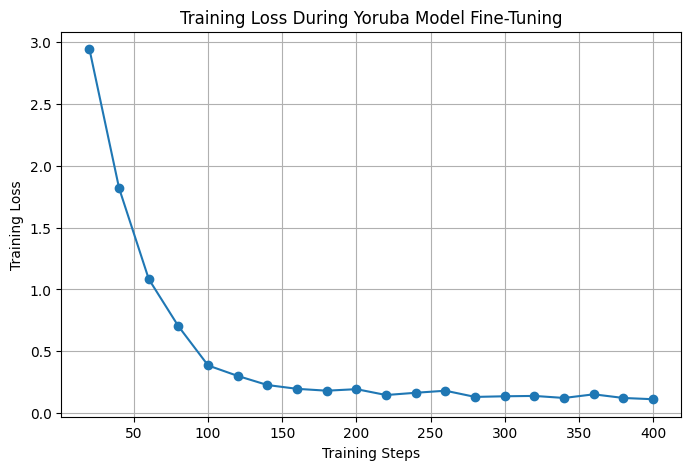

In [26]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

steps = []
losses = []

for x in logs:
    if "loss" in x and "step" in x:
        steps.append(x["step"])
        losses.append(x["loss"])

plt.figure(figsize=(8,5))
plt.plot(steps, losses, marker="o")
plt.xlabel("Training Steps")
plt.ylabel("Training Loss")
plt.title("Training Loss During Yoruba Model Fine-Tuning")
plt.grid(True)
plt.show()

In [27]:
plt.savefig("/content/training_loss_graph.png", dpi=300, bbox_inches="tight")
print("Graph saved successfully.")

Graph saved successfully.


<Figure size 640x480 with 0 Axes>

In [28]:
from google.colab import files
files.download("/content/training_loss_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
!pip install -q sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 3.1 MB/s eta 0:00:00


In [30]:
import sacrebleu

# Use the first 20 test examples
test_data = split["test"].select(range(20))

references = []
predictions = []

for item in test_data:
    prompt = item["text"].split("Assistant:")[0].replace("User:", "").strip()
    reference = item["text"].split("Assistant:")[1].strip()

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False
        )

    prediction = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    predictions.append(prediction)
    references.append(reference)

bleu = sacrebleu.corpus_bleu(predictions, [references])

exact_match = sum(
    p.strip() == r.strip()
    for p, r in zip(predictions, references)
) / len(references) * 100

print("BLEU score:", round(bleu.score, 2))
print("Exact Match:", round(exact_match, 2), "%")

BLEU score: 4.42
Exact Match: 0.0 %


In [31]:
import pandas as pd

error_analysis = pd.DataFrame({
    "Error Category": [
        "Wrong Yoruba response",
        "Poor instruction following",
        "English/multilingual leakage",
        "Repetition",
        "Grammatical/semantic errors"
    ],
    "Observed": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ],
    "Examples": [
        "Expected negative/question forms were not produced correctly",
        "Model often repeated the prompt instead of answering",
        "English and Chinese appeared in some outputs",
        "Several outputs repeated phrases",
        "Generated sentences were often fragmented or nonsensical"
    ]
})

display(error_analysis)

,Error Category,Observed,Examples
0,Wrong Yoruba response,Yes,Expected negative/question forms were not prod...
1,Poor instruction following,Yes,Model often repeated the prompt instead of ans...
2,English/multilingual leakage,Yes,English and Chinese appeared in some outputs
3,Repetition,Yes,Several outputs repeated phrases
4,Grammatical/semantic errors,Yes,Generated sentences were often fragmented or n...


In [32]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Dataset size",
        "Training samples",
        "Validation samples",
        "Epochs",
        "Training loss",
        "Validation loss",
        "Mean token accuracy",
        "BLEU",
        "Exact Match"
    ],
    "Result": [
        3598,
        3238,
        360,
        1,
        0.4671,
        0.1161,
        "95.77%",
        4.42,
        "0%"
    ]
})

display(results)

,Metric,Result
0,Dataset size,3598
1,Training samples,3238
2,Validation samples,360
3,Epochs,1
4,Training loss,0.4671
5,Validation loss,0.1161
6,Mean token accuracy,95.77%
7,BLEU,4.42
8,Exact Match,0%
